# Практическое задание: Преобразование категорий и нормализация признаков

Вы работаете аналитиком в банке. Необходимо подготовить данные о заявителях по кредитам для построения модели машинного обучения, которая ***будет прогнозировать решение по кредитной заявке.***

В качестве исходных данных используется датасет `loan_approval_data_2025.csv`.

**Целевая переменная:**

`loan_status` — результат рассмотрения заявки (например, одобрена или отклонена).

Перед обучением модели необходимо выполнить анализ структуры данных, преобразовать категориальные признаки в числовой формат и подготовить числовые признаки с помощью различных методов масштабирования.

Загрузка датасета:

In [2]:
# Напишите ваш код здесь

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder
)

df = pd.read_csv("Loan_approval_data_2025.csv")
df.head(5)

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


# Задачи для выполнения
# Задача 1: Исследовательский анализ данных
Условие: Проведите исследовательский анализ данных.

Определите:
1. Количество строк и столбцов.
2. Какие признаки являются числовыми, а какие — категориальными.
3. Наличие пропущенных значений.

4. Количество уникальных значений для каждого категориального признака.

5. (*) Построить гистограммы распределения для всех числовых признаков.

6. Сделать краткий вывод о структуре набора данных.

In [3]:
# Напишите ваш код здесь
df.shape

(50000, 20)

In [4]:
df.info()
category_cols = df.select_dtypes(include=["object", "category"]).columns
numeric_cols = df.select_dtypes(include="number").columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [5]:
df.isnull().sum()

,0
customer_id,0
age,0
occupation_status,0
years_employed,0
annual_income,0
credit_score,0
credit_history_years,0
savings_assets,0
current_debt,0
defaults_on_file,0


In [6]:
for col in category_cols:
    print(col, df[col].nunique(), sep=": ")

customer_id: 50000
occupation_status: 3
product_type: 3
loan_intent: 6


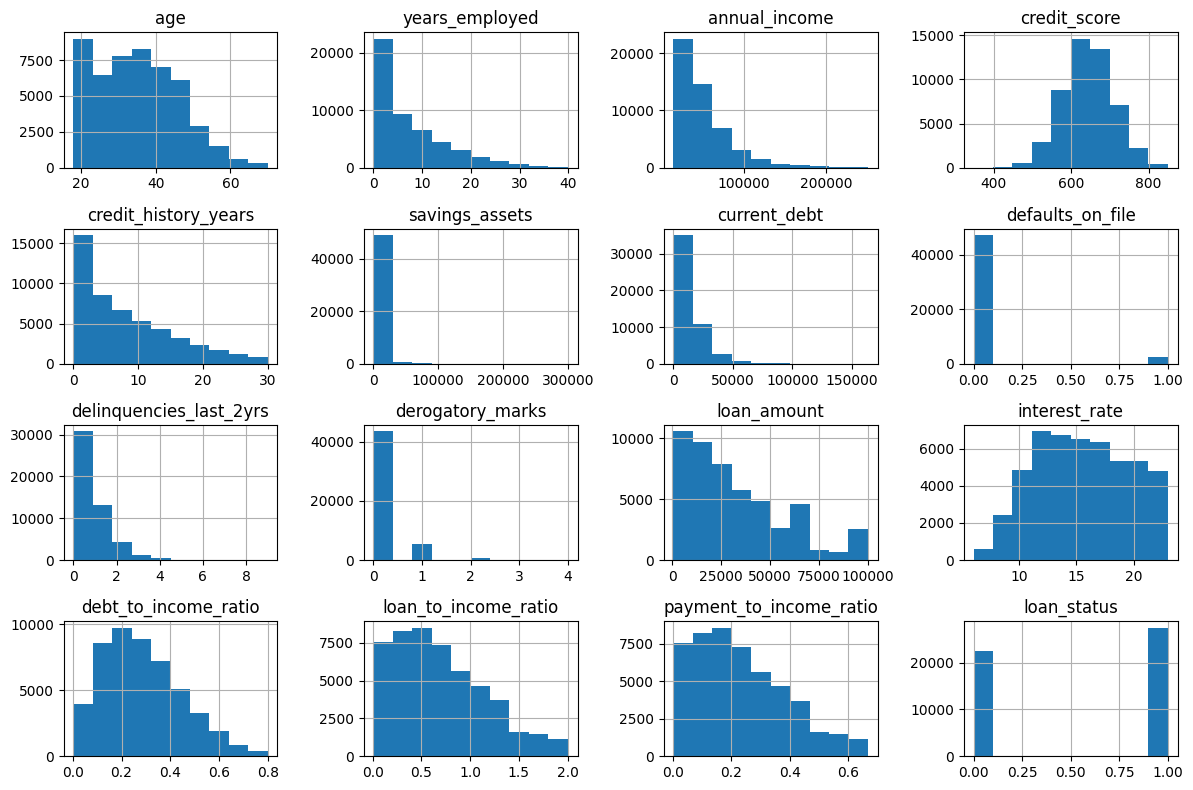

In [7]:
df[numeric_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [8]:
df.describe().round(1)

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
count,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0
mean,35.0,7.5,50062.9,643.6,8.2,3595.6,14290.4,0.1,0.6,0.1,33041.9,15.5,0.3,0.7,0.2,0.6
std,11.1,7.6,32630.5,64.7,7.2,13232.4,13243.8,0.2,0.8,0.4,26116.2,4.1,0.2,0.5,0.2,0.5
min,18.0,0.0,15000.0,348.0,0.0,0.0,60.0,0.0,0.0,0.0,500.0,6.0,0.0,0.0,0.0,0.0
25%,26.0,1.3,27280.5,600.0,2.0,130.0,5581.0,0.0,0.0,0.0,12300.0,12.2,0.2,0.3,0.1,0.0
50%,35.0,4.9,41607.5,643.0,6.1,568.0,10385.0,0.0,0.0,0.0,26100.0,15.4,0.3,0.6,0.2,1.0
75%,43.0,11.4,62723.2,687.0,12.6,2271.0,18449.2,0.0,1.0,0.0,48500.0,18.9,0.4,1.0,0.3,1.0
max,70.0,39.9,250000.0,850.0,30.0,300000.0,163344.0,1.0,9.0,4.0,100000.0,23.0,0.8,2.0,0.7,1.0


# Задача 2: Преобразование категориальных признаков
Перед обучением модели необходимо преобразовать категориальные признаки в числовую форму.

**Требования**
1. Выберите один категориальный признак, имеющий небольшое количество уникальных значений, и выполните для него **Label Encoding**.
2. Выберите один номинальный категориальный признак (например, семейное положение, образование, тип занятости или аналогичный признак из датасета) и выполните **One-Hot Encoding**.
3. Выберите категориальный признак с несколькими повторяющимися категориями и выполните **Frequency Encoding**.
4. Создайте новый DataFrame, содержащий исходные числовые признаки и преобразованные категориальные признаки.
5. Сделайте вывод о том, в каких случаях каждый метод кодирования является наиболее подходящим.

**Примечание.**
` Конкретные признаки выбираются студентом исходя из структуры датасета.`

In [9]:
# Сделайте копию датасета
# Напишите ваш код здесь

df_encoded = df.copy()

# 1
oe = OrdinalEncoder(categories=[["Student", "Self-Employed", "Employed"]])
df_encoded["occupation_status_encoded"] = oe.fit_transform(df_encoded[["occupation_status"]])

# 2
df_encoded = pd.get_dummies(df_encoded, columns=["product_type"])

# 3
freq = df_encoded["loan_intent"].value_counts() / len(df_encoded)
df_encoded["loan_intent_freq"] = df_encoded["loan_intent"].map(freq)

df_encoded.head()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,...,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status,occupation_status_encoded,product_type_Credit Card,product_type_Line of Credit,product_type_Personal Loan,loan_intent_freq
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,...,17.02,0.423,0.023,0.008,1,2.0,True,False,False,0.14938
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,...,14.10,0.384,1.237,0.412,0,2.0,False,False,True,0.14906
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,...,18.33,0.377,0.101,0.034,1,0.0,True,False,False,0.09834
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,...,18.74,0.398,0.099,0.033,1,0.0,True,False,False,0.14938
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,...,13.92,0.195,1.565,0.522,1,2.0,False,False,True,0.20268


# Задача 3: Сравнение методов кодирования
Сравните полученные способы кодирования.
**Требования:**

1. Определите, насколько увеличилось количество признаков после применения **One-Hot Encoding**.
2. Для каждого метода постройте визуализацию (*).

**Например:**
* **для Label Encoding** — столбчатую диаграмму распределения полученных кодов;
* **для One-Hot Encoding** — тепловую карту корреляций между созданными бинарными признаками;
*  для **Frequency Encoding** — график распределения полученных значений.
3. Сравните преимущества и недостатки каждого способа кодирования.
4. Сделайте вывод, какой метод предпочтительнее использовать для различных типов категориальных признаков.


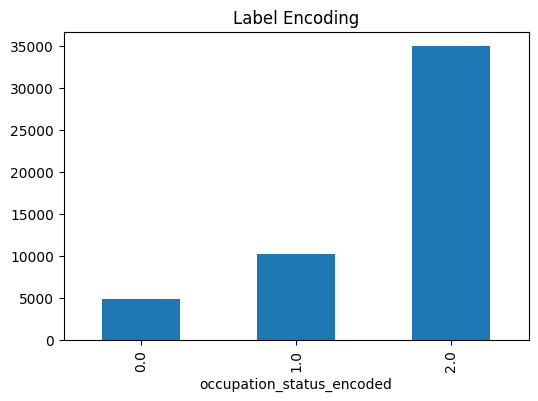

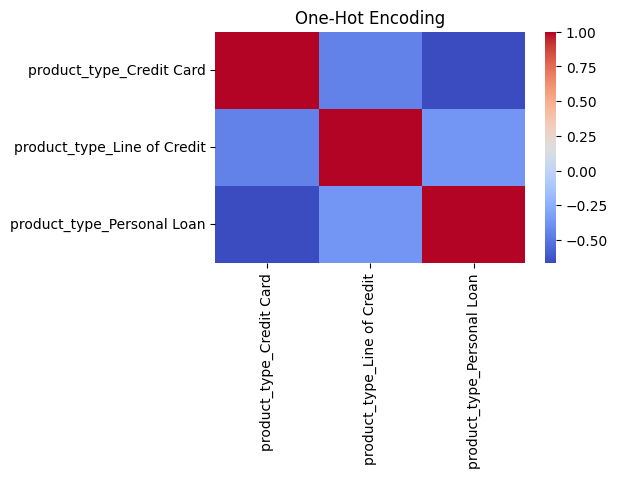

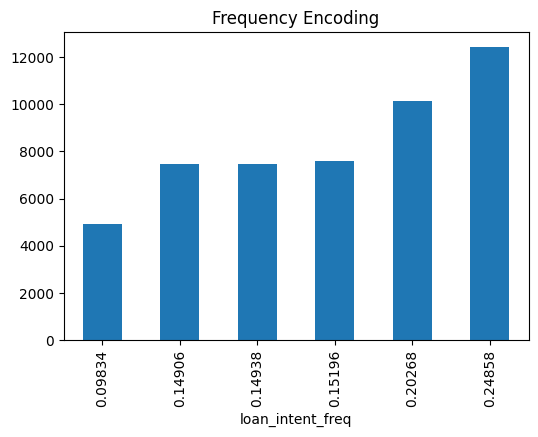

In [10]:
# Сделайте копию датасета
# Напишите ваш код здесь

# 1 -- на количество уникальных значенией в кодируемом столбце, то есть на 3

# 2
# Label Encoding
plt.figure(figsize=(6, 4))
df_encoded["occupation_status_encoded"].value_counts().sort_index().plot(kind="bar")
plt.title("Label Encoding")
plt.show()
print()

# One-Hot Encoding
plt.figure(figsize=(5, 3))
sns.heatmap(df_encoded[['product_type_Credit Card',	'product_type_Line of Credit', 'product_type_Personal Loan']].corr(), cmap="coolwarm")
plt.title("One-Hot Encoding")
plt.show()
print()

# Frequency Encoding
plt.figure(figsize=(6, 4))
df_encoded["loan_intent_freq"].value_counts().sort_index().plot(kind="bar")
plt.title("Frequency Encoding")
plt.show()


# Задача 4: Масштабирование числовых признаков
Подготовьте числовые признаки к использованию в модели машинного обучения

**Требования**
1. Выберите два числовых признака, характеризующих клиента (например, возраст, доход, стаж работы или аналогичные признаки из датасета), и примените **Min-Max Scaling**.
2. Выберите два других числовых признака и выполните **Standard Scaling**.
3. Для одного числового признака выполните **Robust Scaling** и сравните результат со **Standard Scaling**.
4. (*)Постройте boxplot для выбранных признаков:
* до масштабирования;
* после масштабирования.
5. Рассчитайте основные статистики (**среднее значение, стандартное отклонение, минимум и максимум)** до и после преобразований.
6. Сделайте вывод о том, как различные методы масштабирования влияют на данные и в каких случаях каждый из них рекомендуется использовать.

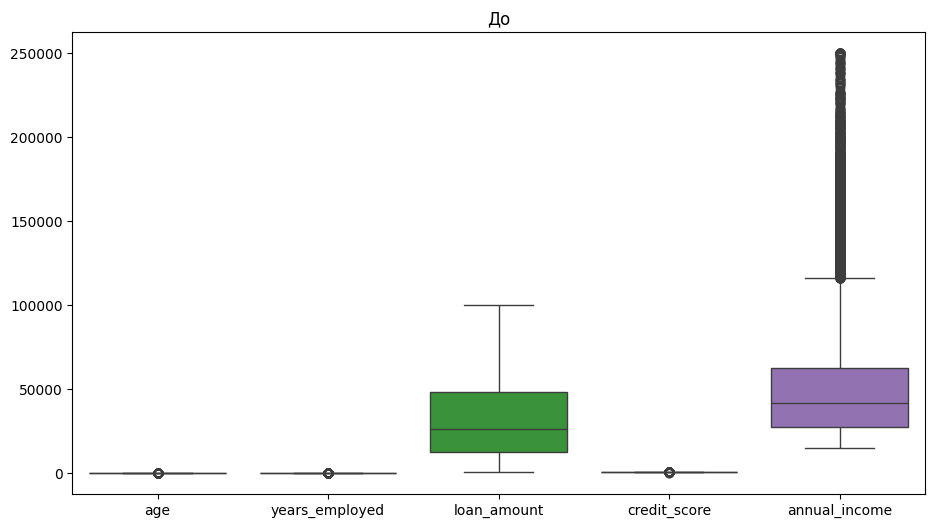

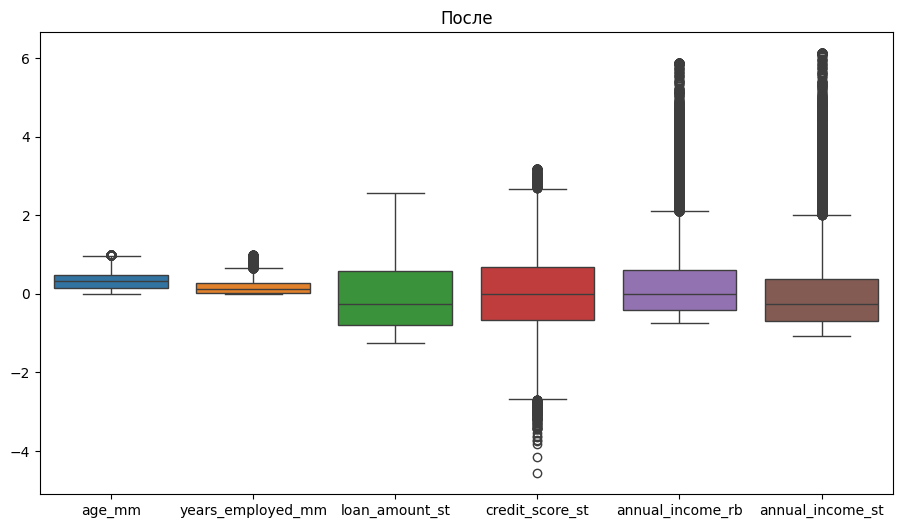

,age,age_mm,years_employed,years_employed_mm,loan_amount,loan_amount_st,credit_score,credit_score_st,annual_income,annual_income_rb,annual_income_st
mean,35.0,0.3,7.5,0.2,33041.9,-0.0,643.6,-0.0,50062.9,0.2,0.0
std,11.1,0.2,7.6,0.2,26116.2,1.0,64.7,1.0,32630.5,0.9,1.0
min,18.0,0.0,0.0,0.0,500.0,-1.2,348.0,-4.6,15000.0,-0.8,-1.1
max,70.0,1.0,39.9,1.0,100000.0,2.6,850.0,3.2,250000.0,5.9,6.1


In [21]:
# Сделайте копию датасета
# Напишите ваш код здесь
df_scaled = df_encoded.copy()

# 1
df_scaled[["age_mm", "years_employed_mm"]] = MinMaxScaler().fit_transform(df_scaled[["age", "years_employed"]])

# 2
df_scaled[["loan_amount_st", "credit_score_st"]] = StandardScaler().fit_transform(df_scaled[["loan_amount", "credit_score"]])

# 3
rb = RobustScaler()
df_scaled["annual_income_rb"] = RobustScaler().fit_transform(df_scaled[["annual_income"]])
df_scaled["annual_income_st"] = StandardScaler().fit_transform(df_scaled[["annual_income"]])

# 4
plt.figure(figsize=(11, 6))
sns.boxplot(data=df_encoded[["age", "years_employed", "loan_amount", "credit_score", "annual_income"]])
plt.title("До")
plt.show()
print()

plt.figure(figsize=(11, 6))
sns.boxplot(data=df_scaled[["age_mm", "years_employed_mm", "loan_amount_st", "credit_score_st", "annual_income_rb", "annual_income_st"]])
plt.title("После")
plt.show()

# 5
cols_stat = ["age", "age_mm", "years_employed", "years_employed_mm", "loan_amount", "loan_amount_st", "credit_score", "credit_score_st",
             "annual_income", "annual_income_rb", "annual_income_st"]
df_scaled[cols_stat].describe().loc[['mean', 'std', 'min', 'max']].round(1)

## Итоговое задание

Подготовьте набор данных к дальнейшему использованию в задачах машинного обучения.

В результате работы необходимо:

* получить набор данных, содержащий только признаки, пригодные для обучения модели
* преобразовать выбранные категориальные признаки в числовой формат
* выполнить масштабирование выбранных числовых признаков
* сохранить подготовленный DataFrame для дальнейшего использования

In [28]:
df_scaled["savings_assets_log"] = np.log1p(df_scaled["savings_assets"])
df_scaled["savings_assets_log_st"] = StandardScaler().fit_transform(df_scaled[["savings_assets_log"]])